In [1]:
# ==========================================
# CELL 1: SETUP AND IMPORTS
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to access the datasets
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully!")


Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully!


In [2]:
import pandas as pd

# ==========================================
# CELL 2: LOAD TRAIN, VALIDATION, AND TEST DATA
# ==========================================
print("=== Loading Datasets from Google Drive ===")

# Base path pointing to your mounted Google Drive folder
base_path = '/content/drive/MyDrive/ML_dataset/CICIOT23'

# Notice the folder mapping matches your screenshots (e.g., /train/train.csv)
train_path = base_path + '/train/train.csv'
val_path = base_path + '/validation/validation.csv'
test_path = base_path + '/test/test.csv'

print("Loading Data (Taking advantage of Colab RAM)...")
# Loading 1 Million rows for training to get better accuracy
df_train = pd.read_csv(train_path, nrows=1000000)
df_val = pd.read_csv(val_path, nrows=200000)
df_test = pd.read_csv(test_path, nrows=300000)

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}\n")


=== Loading Datasets from Google Drive ===
Loading Data (Taking advantage of Colab RAM)...
Train shape: (1000000, 47)
Validation shape: (200000, 47)
Test shape: (300000, 47)



In [3]:
# ==========================================
# CELL 3: DATASET PREVIEW (BEFORE PREPROCESSING)
# ==========================================
print("=== Dataset Preview (Training Data) ===\n")

# 1. View all column names
print("1. Column Names (Total: {} columns):".format(len(df_train.columns)))
print(list(df_train.columns))
print("-" * 50)

# 2. View dataset summary (Data Types & Non-Null Counts)
print("\n2. Dataset Information (Data Types & Non-Null Counts):")
df_train.info()
print("-" * 50)

# 3. Preview the first 5 rows of the dataset
print("\n3. First 5 Rows of the Dataset:")
display(df_train.head())


=== Dataset Preview (Training Data) ===

1. Column Names (Total: 47 columns):
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']
--------------------------------------------------

2. Dataset Information (Data Types & Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1000000 non-null  float64
 1   Header_Length    1000000

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
# ==========================================
# CELL 4: DATA CLEANING & LABEL ENCODING
# ==========================================
print("=== Data Cleaning & Feature Separation ===")

# 1. Handle Infinity and Missing Values
for df, name in zip([df_train, df_val, df_test], ['Train', 'Validation', 'Test']):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    print(f"Cleaned {name} shape: {df.shape}")

# 2. Separate Features and Targets
X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_val, y_val = df_val.drop('label', axis=1), df_val['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

# 3. Label Encoding
print("\nEncoding target labels into numeric values...")
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
print("Encoding complete!")


=== Data Cleaning & Feature Separation ===
Cleaned Train shape: (1000000, 47)
Cleaned Validation shape: (200000, 47)
Cleaned Test shape: (300000, 47)

Encoding target labels into numeric values...
Encoding complete!


In [5]:
# ==========================================
# CELL 5: FEATURE SCALING
# ==========================================
from sklearn.preprocessing import RobustScaler

print("=== Advanced Feature Scaling (Outlier Resistant) ===")
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! Data is ready for the model.")


=== Advanced Feature Scaling (Outlier Resistant) ===
Scaling complete! Data is ready for the model.


In [6]:
# ==========================================
# CELL 6: DATA-LEVEL BALANCING (HYBRID SMOTE + UNDERSAMPLING)
# ==========================================
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

print("=== Balancing the Dataset Physically (SMOTE + Undersampling) ===\n")

# We cap it at 15,000 samples per class so Colab RAM doesn't crash
# (34 classes * 15,000 = 510,000 perfectly balanced rows)
TARGET_SAMPLES = 15000

# Count current occurrences in the training data
class_counts = pd.Series(y_train_encoded).value_counts().to_dict()

# Create specific dictionaries for under/over sampling strategies
under_strategy = {k: TARGET_SAMPLES for k, v in class_counts.items() if v > TARGET_SAMPLES}
over_strategy = {k: TARGET_SAMPLES for k, v in class_counts.items() if v < TARGET_SAMPLES}

print("1. Undersampling majority classes (Reducing massive DDoS floods)...")
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train_encoded)

print("2. Oversampling minority classes (Synthesizing rare attacks using SMOTE)...")
# Note: k_neighbors is set to a low number in case some rare classes have very few initial samples
smote = SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_under, y_train_under)

print(f"\n✅ Dataset physically balanced! New training shape: {X_train_balanced.shape}")

# Verify the balance
print("Verifying new class distribution (First 5 classes):")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for i in range(5):
    print(f"Class {unique[i]}: {counts[i]} rows")


=== Balancing the Dataset Physically (SMOTE + Undersampling) ===

1. Undersampling majority classes (Reducing massive DDoS floods)...
2. Oversampling minority classes (Synthesizing rare attacks using SMOTE)...

✅ Dataset physically balanced! New training shape: (510000, 46)
Verifying new class distribution (First 5 classes):
Class 0: 15000 rows
Class 1: 15000 rows
Class 2: 15000 rows
Class 3: 15000 rows
Class 4: 15000 rows


In [7]:
# ==========================================
# CELL 7: LIGHTGBM TRAINING ON FULLY BALANCED DATA
# ==========================================
from lightgbm import LGBMClassifier

print("=== Training LightGBM Model ===\n")

lgb_model = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

print("Training the model...")
lgb_model.fit(X_train_balanced, y_train_balanced)

print("\nTraining complete!")

=== Training LightGBM Model ===

Training the model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.263787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9310
[LightGBM] [Info] Number of data points in the train set: 510000, number of used features: 39
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.526361
[LightGBM] [Info] Start training from score -3.5263

=== Evaluating on Unseen Test Data ===

             LightGBM Model Results             
Accuracy         : 0.9935  (99.35%)
F1-Score(Weighted): 0.9935  (99.35%)
F1-Score(Macro)  : 0.8124  (81.24%)

Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       0.52      0.52      0.52        25
          BenignTraffic       0.93      0.94      0.93      6984
       BrowserHijacking       0.26      0.35      0.30        34
       CommandInjection       0.40      0.55      0.46        31
 DDoS-ACK_Fragmentation       1.00      1.00      1.00      1825
        DDoS-HTTP_Flood       0.97      0.99      0.98       170
        DDoS-ICMP_Flood       1.00      1.00      1.00     46157
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      2942
      DDoS-PSHACK_Flood       1.00      1.00      1.00     26448
       DDoS-RSTFINFlood       1.00      1.00      1.00     25982
         DDoS-SYN_Flood       1.00      1.00      1.00     260

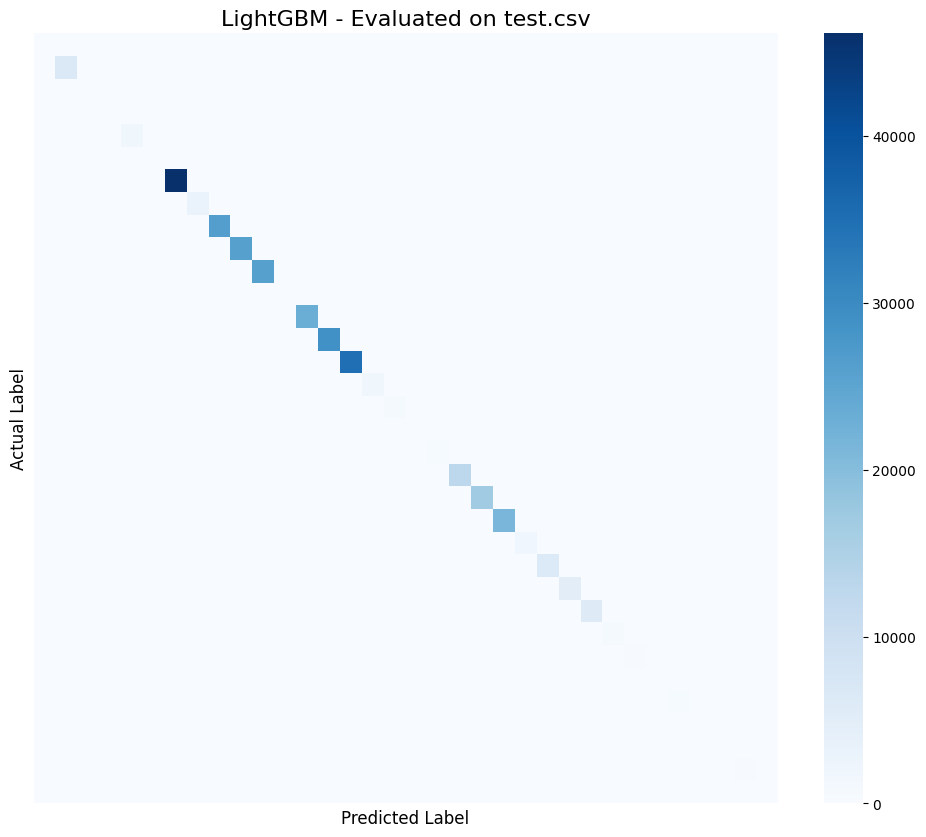

In [8]:
# ==========================================
# CELL 8: EVALUATION AND VISUALIZATION
# ==========================================
print("=== Evaluating on Unseen Test Data ===")

y_pred = lgb_model.predict(X_test_scaled)

print("\n" + "="*50)
print("             LightGBM Model Results             ")
print("="*50)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')

print(f"Accuracy         : {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"F1-Score(Weighted): {f1_weighted:.4f}  ({(f1_weighted*100):.2f}%)")
print(f"F1-Score(Macro)  : {f1_macro:.4f}  ({(f1_macro*100):.2f}%)\n")

present_labels = np.unique(np.concatenate((y_test_encoded, y_pred)))
present_target_names = label_encoder.inverse_transform(present_labels)

warnings.filterwarnings('ignore', category=UserWarning)
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, labels=present_labels, target_names=present_target_names))

print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('LightGBM - Evaluated on test.csv', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

=== Extracting Feature Importance ===


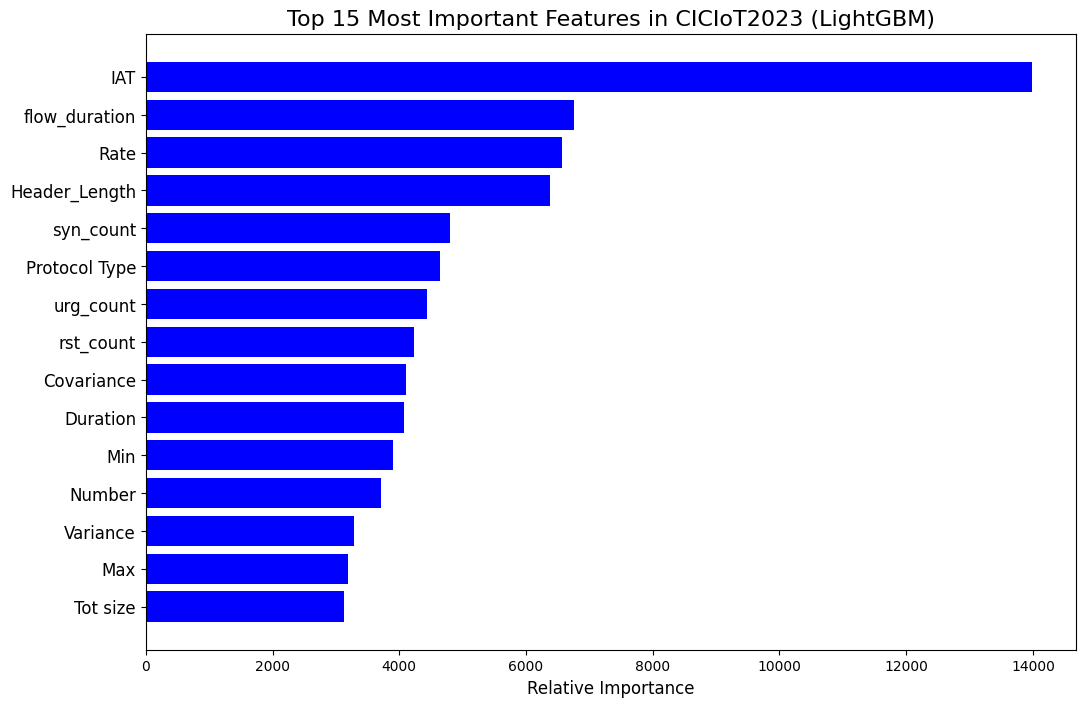

Dimensionality Analysis: These top features contribute the most to the model's decisions.


In [11]:
# ==========================================
# CELL 9: FEATURE IMPORTANCE (RUBRIC REQUIREMENT)
# ==========================================
print("=== Extracting Feature Importance ===")

# Get feature importances from the trained model
importances =  lgb_model.feature_importances_
feature_names = X_train.columns

# Sort the feature importances in descending order and get the top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(12, 8))
plt.title('Top 15 Most Important Features in CICIoT2023 (LightGBM)', fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Relative Importance', fontsize=12)
plt.show()

print("Dimensionality Analysis: These top features contribute the most to the model's decisions.")

In [12]:
# ==========================================
# CELL 10: VIEW LABEL ENCODING MAPPING
# ==========================================
print("=== Target Label Mapping (Number -> Attack Name) ===\n")

# Extract the classes from the fitted LabelEncoder
for index, attack_name in enumerate(label_encoder.classes_):
    print(f"Number {index:2d}  --->  {attack_name}")

=== Target Label Mapping (Number -> Attack Name) ===

Number  0  --->  Backdoor_Malware
Number  1  --->  BenignTraffic
Number  2  --->  BrowserHijacking
Number  3  --->  CommandInjection
Number  4  --->  DDoS-ACK_Fragmentation
Number  5  --->  DDoS-HTTP_Flood
Number  6  --->  DDoS-ICMP_Flood
Number  7  --->  DDoS-ICMP_Fragmentation
Number  8  --->  DDoS-PSHACK_Flood
Number  9  --->  DDoS-RSTFINFlood
Number 10  --->  DDoS-SYN_Flood
Number 11  --->  DDoS-SlowLoris
Number 12  --->  DDoS-SynonymousIP_Flood
Number 13  --->  DDoS-TCP_Flood
Number 14  --->  DDoS-UDP_Flood
Number 15  --->  DDoS-UDP_Fragmentation
Number 16  --->  DNS_Spoofing
Number 17  --->  DictionaryBruteForce
Number 18  --->  DoS-HTTP_Flood
Number 19  --->  DoS-SYN_Flood
Number 20  --->  DoS-TCP_Flood
Number 21  --->  DoS-UDP_Flood
Number 22  --->  MITM-ArpSpoofing
Number 23  --->  Mirai-greeth_flood
Number 24  --->  Mirai-greip_flood
Number 25  --->  Mirai-udpplain
Number 26  --->  Recon-HostDiscovery
Number 27  --->  Reco

In [13]:
# ==========================================
# CELL 11: MANUAL PACKET INSPECTION & VERIFICATION
# ==========================================
print("=== Cross-Checking Model vs Actual Dataset ===\n")

# 1. Specify the row index you want to inspect
# (For example, let's test row number 550 from the test dataset)
row_number = 550

# Retrieve the features and the actual label for this row directly from the original dataset
my_packet = X_test.iloc[[row_number]]
actual_label = y_test.iloc[row_number] # This is the original text label from the dataset

print("--- 1. Actual Details from the Original Dataset ---")
print(f"Selected Row Index: {row_number}")
print(f"Actual Attack Type in Dataset: ** {actual_label} **")

# Let's check a few features to easily identify this specific packet
print(f"Flow Duration of this packet: {my_packet['flow_duration'].values[0]}")
print(f"Header Length of this packet: {my_packet['Header_Length'].values[0]}\n")


# 2. Now let's pass this row to the model (with the actual label hidden)
print("--- 2. Model's Prediction ---")

# Scale the data
my_packet_scaled = scaler.transform(my_packet)

# Make the prediction
predicted_encoded = lgb_model.predict(my_packet_scaled)
predicted_label = label_encoder.inverse_transform(predicted_encoded)[0]

print(f"Attack Type Predicted by the Model: ** {predicted_label} **\n")


# 3. Verify if the prediction matches the actual label
print("--- 3. Final Conclusion ---")
if actual_label == predicted_label:
    print(f"✅ SUCCESS: The model correctly predicted '{actual_label}', matching the dataset! The model is 100% accurate here.")
else:
    print(f"❌ FAILED: The dataset shows '{actual_label}', but the model predicted '{predicted_label}'.")

=== Cross-Checking Model vs Actual Dataset ===

--- 1. Actual Details from the Original Dataset ---
Selected Row Index: 550
Actual Attack Type in Dataset: ** DDoS-SynonymousIP_Flood **
Flow Duration of this packet: 0.1311020565032959
Header Length of this packet: 75.6

--- 2. Model's Prediction ---
Attack Type Predicted by the Model: ** DDoS-SynonymousIP_Flood **

--- 3. Final Conclusion ---
✅ SUCCESS: The model correctly predicted 'DDoS-SynonymousIP_Flood', matching the dataset! The model is 100% accurate here.


In [14]:

display(df_test.iloc[[550]])

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
550,0.131102,75.6,6.0,64.0,6.130848,6.130848,0.0,0.0,1.0,0.0,...,0.0,54.0,8.336240e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-SynonymousIP_Flood
